In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

In [39]:
# Caminho para o arquivo Parquet
caminho_parquet = r"C:\Users\Pichau\INMET\TODAS_ESTACOES\TODAS_ESTACOES_CONCATENADO.parquet"

# Ler o arquivo Parquet
df = pd.read_parquet(caminho_parquet)

In [40]:
# Função para calcular a maior diferença de pressão nas duas horas anteriores
def calcular_maior_diferenca(grupo):
    grupo = grupo.copy()
    
    grupo['MAIOR_DIFERENCA_PRESSAO_2H_ATRAS'] = (
        grupo['Pres_Atm_max'].rolling(window=2, min_periods=2).max() - 
        grupo['Pres_Atm_min'].rolling(window=2, min_periods=2).min()
    )

    grupo['MAIOR_DIFERENCA_PRESSAO_3H_ATRAS'] = (
        grupo['Pres_Atm_max'].rolling(window=3, min_periods=3).max() - 
        grupo['Pres_Atm_min'].rolling(window=3, min_periods=3).min()
    )
    
    return grupo

# Avaliando correlação de pressão: FORTE DE COPACABANA.

In [42]:
COPACABANA = df[df['ESTACAO'] == 'FORTE_COPACABANA']

In [43]:
# Variáveis que quero usar. 
variaveis = ['Dt_Hr', 'ESTACAO','Precip', 'Pres_Atm_max','Pres_Atm_min',
             'VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO',
             'VARIACAO SEGUNDA HORA ANTERIOR PRESSAO',
             'VARIACAO TERCEIRA HORA ANTERIOR PRESSAO']

COPACABANA = COPACABANA[variaveis]


In [44]:
# Tirando esses nulos.

# Substitui os valores -9999 por NaN
COPACABANA.replace(-9999, np.nan, inplace=True)

# Conta a quantidade de valores nulos em cada coluna
missing_values = COPACABANA.isnull().sum()

# Exibe a quantidade de valores nulos
print(missing_values)

# Total de valores nulos no DataFrame
total_missing_values = COPACABANA.isnull().sum().sum()
print("Total de valores nulos no DataFrame:", total_missing_values)


Dt_Hr                                         0
ESTACAO                                       0
Precip                                     5682
Pres_Atm_max                               3023
Pres_Atm_min                               3023
VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO    1986
VARIACAO SEGUNDA HORA ANTERIOR PRESSAO     1987
VARIACAO TERCEIRA HORA ANTERIOR PRESSAO    1988
dtype: int64
Total de valores nulos no DataFrame: 17689


In [45]:
len(COPACABANA) 
5682/153768 , # 3% dos dados são nulos. 

(0.03695177149992196,)

In [46]:
COPACABANA = COPACABANA.dropna(subset=['Precip'])

In [47]:
COPACABANA = COPACABANA.reset_index(drop=True)

COPACABANA = COPACABANA.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)

C:\Users\Pichau\AppData\Local\Temp\ipykernel_8236\3785596157.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  COPACABANA = COPACABANA.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


In [48]:
COPACABANA_CHUVA = COPACABANA[(COPACABANA['Precip'] > 0) & (COPACABANA['Precip'] < 25)]

COPACABANA_CHUVA_EXTREMA = COPACABANA[COPACABANA['Precip'] >= 25]


In [49]:
variaveis = ['Precip','VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO','VARIACAO SEGUNDA HORA ANTERIOR PRESSAO','VARIACAO TERCEIRA HORA ANTERIOR PRESSAO',
             'MAIOR_DIFERENCA_PRESSAO_2H_ATRAS','MAIOR_DIFERENCA_PRESSAO_3H_ATRAS'
            
            ]

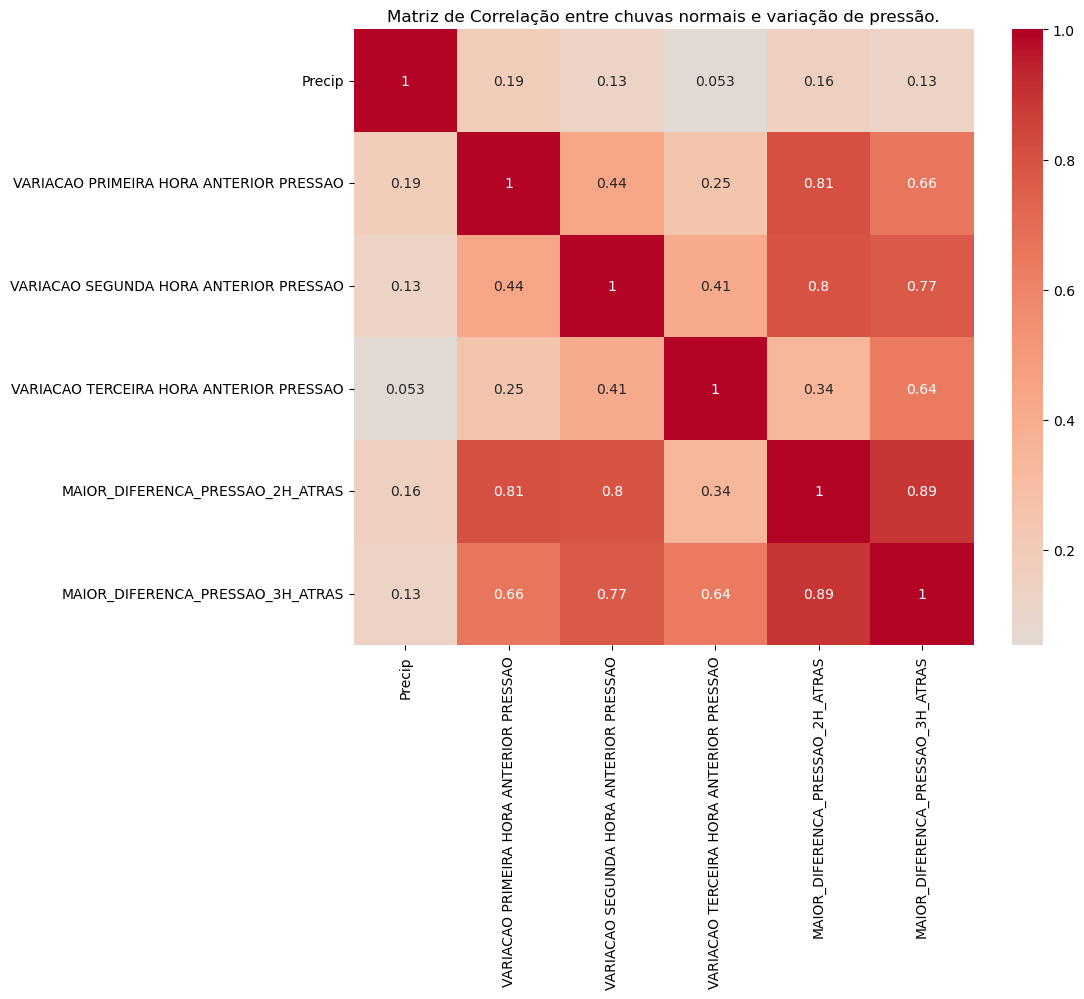

In [50]:
# Calcula a matriz de correlação
correlation_matrix = COPACABANA_CHUVA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas normais e variação de pressão.')

# Exibe o gráfico
plt.show()

Text(0.5, 1.0, 'Matriz de Correlação entre chuvas extremas e variação de pressão.')

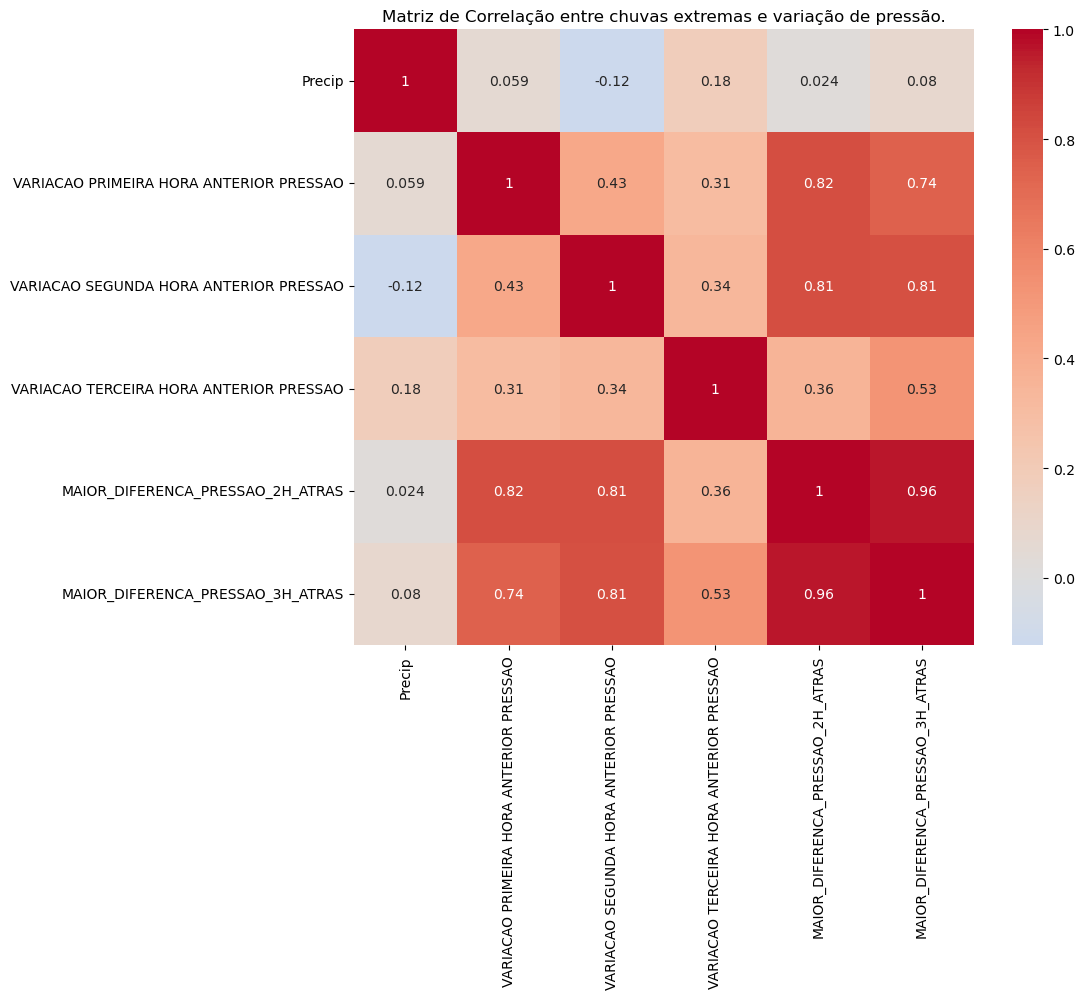

In [51]:
# Calcula a matriz de correlação
correlation_matrix = COPACABANA_CHUVA_EXTREMA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas extremas e variação de pressão.')

In [52]:
COPACABANA_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'].describe()

count    12600.000000
mean         0.568968
std          0.387927
min          0.000000
25%          0.300000
50%          0.500000
75%          0.700000
max          6.500000
Name: VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO, dtype: float64

In [53]:
COPACABANA_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'].describe()

count    48.000000
mean      1.162500
std       0.716262
min       0.300000
25%       0.600000
50%       1.000000
75%       1.600000
max       3.900000
Name: VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO, dtype: float64

In [54]:
COPACABANA_CHUVA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'].describe()

count    12594.000000
mean         0.545895
std          0.356123
min          0.000000
25%          0.300000
50%          0.500000
75%          0.700000
max          5.200000
Name: VARIACAO TERCEIRA HORA ANTERIOR PRESSAO, dtype: float64

In [55]:
COPACABANA_CHUVA_EXTREMA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'].describe()

count    48.000000
mean      0.572917
std       0.267168
min       0.100000
25%       0.400000
50%       0.550000
75%       0.700000
max       1.400000
Name: VARIACAO TERCEIRA HORA ANTERIOR PRESSAO, dtype: float64

In [56]:
COPACABANA_CHUVA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO,VARIACAO SEGUNDA HORA ANTERIOR PRESSAO,VARIACAO TERCEIRA HORA ANTERIOR PRESSAO,MAIOR_DIFERENCA_PRESSAO_2H_ATRAS,MAIOR_DIFERENCA_PRESSAO_3H_ATRAS
count,12602.000000,12600.000000,12596.000000,12594.000000,12589.000000,12584.000000
mean,1.405507,0.568968,0.560972,0.545895,1.004123,1.394374
std,2.467694,0.387927,0.377425,0.356123,0.608841,0.778710
min,0.200000,0.000000,0.000000,0.000000,0.000000,0.100000
25%,0.200000,0.300000,0.300000,0.300000,0.600000,0.800000
50%,0.600000,0.500000,0.500000,0.500000,0.900000,1.300000
75%,1.400000,0.700000,0.700000,0.700000,1.300000,1.800000
max,24.800000,6.500000,5.200000,5.200000,9.500000,10.700000


In [57]:
COPACABANA_CHUVA_EXTREMA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO,VARIACAO SEGUNDA HORA ANTERIOR PRESSAO,VARIACAO TERCEIRA HORA ANTERIOR PRESSAO,MAIOR_DIFERENCA_PRESSAO_2H_ATRAS,MAIOR_DIFERENCA_PRESSAO_3H_ATRAS
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,36.804167,1.162500,0.914583,0.572917,1.808333,2.187500
std,11.505595,0.716262,0.707404,0.267168,1.079565,1.144018
min,25.200000,0.300000,0.200000,0.100000,0.400000,0.500000
25%,28.800000,0.600000,0.500000,0.400000,0.975000,1.200000
50%,33.400000,1.000000,0.700000,0.550000,1.700000,2.100000
75%,37.950000,1.600000,1.125000,0.700000,2.325000,2.700000
max,71.600000,3.900000,3.400000,1.400000,6.000000,6.000000


# Avaliação de correlação de pressão: JACAREPAGUA

In [59]:
JACAREPAGUA = df[df['ESTACAO'] == 'JACAREPAGUA']

In [60]:
variaveis = ['Dt_Hr', 'ESTACAO','Precip', 'Pres_Atm_max','Pres_Atm_min',
             'VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO',
             'VARIACAO SEGUNDA HORA ANTERIOR PRESSAO',
             'VARIACAO TERCEIRA HORA ANTERIOR PRESSAO']

JACAREPAGUA = JACAREPAGUA[variaveis]

# Tirando esses nulos.

# Substitui os valores -9999 por NaN
JACAREPAGUA.replace(-9999, np.nan, inplace=True)

# Conta a quantidade de valores nulos em cada coluna
missing_values = JACAREPAGUA.isnull().sum()

# Exibe a quantidade de valores nulos
print(missing_values)

# Total de valores nulos no DataFrame
total_missing_values = JACAREPAGUA.isnull().sum().sum()
print("Total de valores nulos no DataFrame:", total_missing_values) 

len(JACAREPAGUA) 

JACAREPAGUA = JACAREPAGUA.dropna(subset=['Precip'])

JACAREPAGUA = JACAREPAGUA.reset_index(drop=True)

JACAREPAGUA = JACAREPAGUA.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)

JACAREPAGUA_CHUVA = JACAREPAGUA[(JACAREPAGUA['Precip'] > 0) & (JACAREPAGUA['Precip'] < 25)]

JACAREPAGUA_CHUVA_EXTREMA = JACAREPAGUA[JACAREPAGUA['Precip'] >= 25]

variaveis = ['Precip','VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO','VARIACAO SEGUNDA HORA ANTERIOR PRESSAO','VARIACAO TERCEIRA HORA ANTERIOR PRESSAO',
             'MAIOR_DIFERENCA_PRESSAO_2H_ATRAS','MAIOR_DIFERENCA_PRESSAO_3H_ATRAS'
            
            ]
            
            

Dt_Hr                                         0
ESTACAO                                       0
Precip                                      729
Pres_Atm_max                               3718
Pres_Atm_min                               3718
VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO     702
VARIACAO SEGUNDA HORA ANTERIOR PRESSAO      703
VARIACAO TERCEIRA HORA ANTERIOR PRESSAO     704
dtype: int64
Total de valores nulos no DataFrame: 10274


C:\Users\Pichau\AppData\Local\Temp\ipykernel_8236\841032215.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  JACAREPAGUA = JACAREPAGUA.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


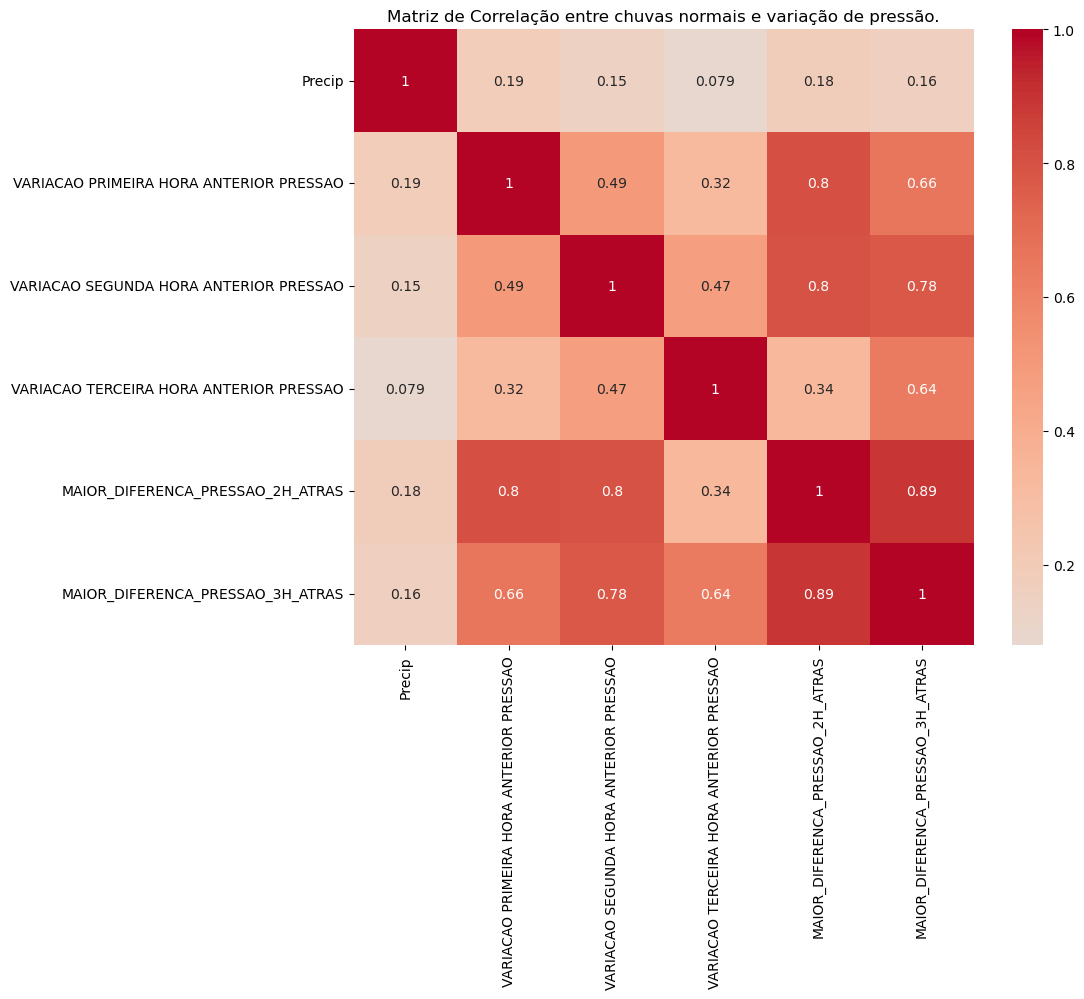

In [61]:
# Calcula a matriz de correlação
correlation_matrix = JACAREPAGUA_CHUVA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas normais e variação de pressão.')

# Exibe o gráfico
plt.show()

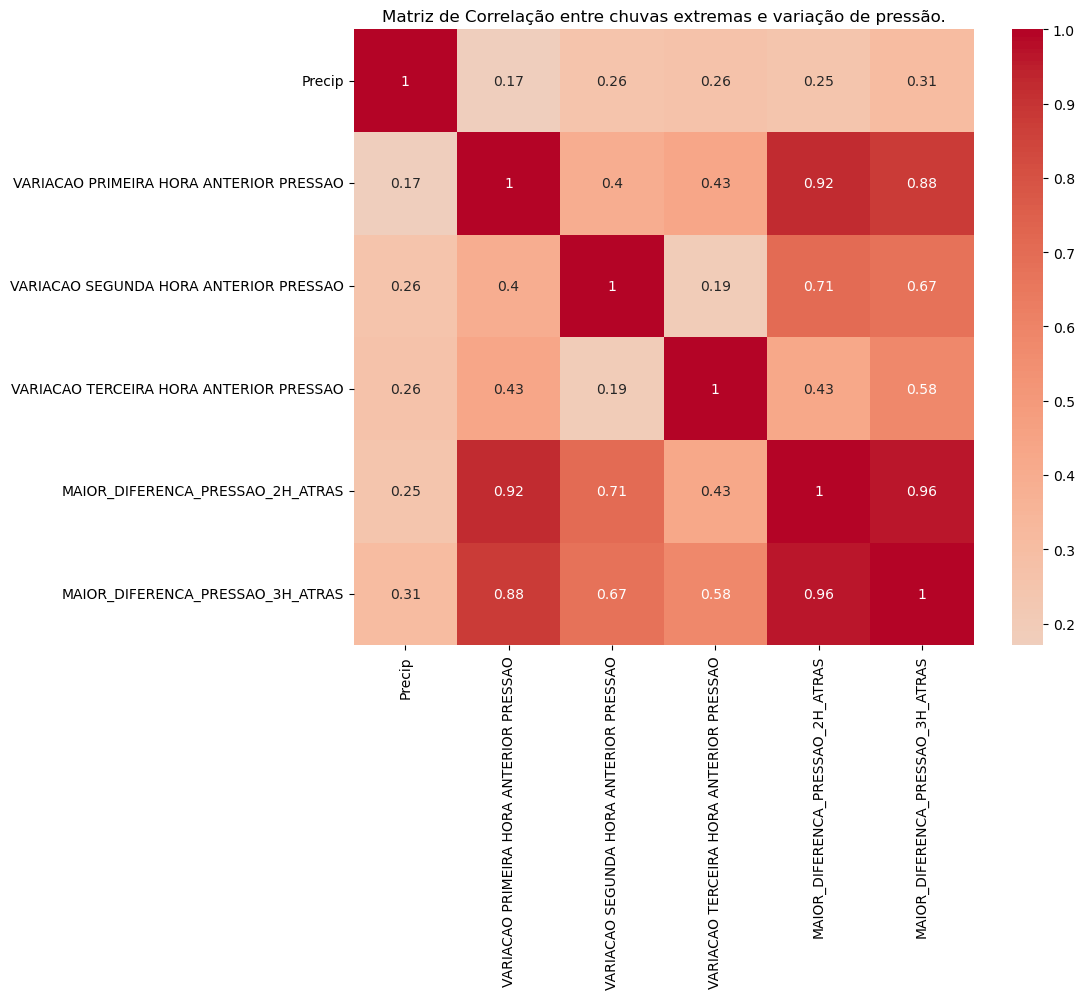

In [62]:
# Calcula a matriz de correlação
correlation_matrix = JACAREPAGUA_CHUVA_EXTREMA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas extremas e variação de pressão.') 

plt.show()

In [63]:
print("JACAREPAGUA_CHUVA - VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO:")
print(JACAREPAGUA_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'].describe())

print("\nJACAREPAGUA_CHUVA_EXTREMA - VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO:")
print(JACAREPAGUA_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'].describe())

print("\nJACAREPAGUA_CHUVA - VARIACAO TERCEIRA HORA ANTERIOR PRESSAO:")
print(JACAREPAGUA_CHUVA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'].describe())

print("\nJACAREPAGUA_CHUVA_EXTREMA - VARIACAO TERCEIRA HORA ANTERIOR PRESSAO:")
print(JACAREPAGUA_CHUVA_EXTREMA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'].describe())


JACAREPAGUA_CHUVA - VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO:
count    5634.000000
mean        0.561732
std         0.375329
min         0.000000
25%         0.300000
50%         0.500000
75%         0.700000
max         3.900000
Name: VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO, dtype: float64

JACAREPAGUA_CHUVA_EXTREMA - VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO:
count    31.000000
mean      1.280645
std       0.867725
min       0.400000
25%       0.700000
50%       1.100000
75%       1.650000
max       4.400000
Name: VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO, dtype: float64

JACAREPAGUA_CHUVA - VARIACAO TERCEIRA HORA ANTERIOR PRESSAO:
count    5616.000000
mean        0.542450
std         0.367737
min         0.000000
25%         0.300000
50%         0.500000
75%         0.700000
max         4.400000
Name: VARIACAO TERCEIRA HORA ANTERIOR PRESSAO, dtype: float64

JACAREPAGUA_CHUVA_EXTREMA - VARIACAO TERCEIRA HORA ANTERIOR PRESSAO:
count    31.000000
mean      0.535484
std       0.292744
min   

In [64]:
JACAREPAGUA_CHUVA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO,VARIACAO SEGUNDA HORA ANTERIOR PRESSAO,VARIACAO TERCEIRA HORA ANTERIOR PRESSAO,MAIOR_DIFERENCA_PRESSAO_2H_ATRAS,MAIOR_DIFERENCA_PRESSAO_3H_ATRAS
count,5635.000000,5634.000000,5623.000000,5616.000000,5401.000000,5400.000000
mean,1.739840,0.561732,0.557425,0.542450,1.029106,1.426259
std,2.863794,0.375329,0.381194,0.367737,0.596186,0.782440
min,0.200000,0.000000,0.000000,0.000000,0.100000,0.100000
25%,0.200000,0.300000,0.300000,0.300000,0.600000,0.900000
50%,0.600000,0.500000,0.500000,0.500000,0.900000,1.300000
75%,2.000000,0.700000,0.700000,0.700000,1.300000,1.800000
max,24.800000,3.900000,4.400000,4.400000,5.600000,6.300000


In [126]:
JACAREPAGUA_CHUVA_EXTREMA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO,VARIACAO SEGUNDA HORA ANTERIOR PRESSAO,VARIACAO TERCEIRA HORA ANTERIOR PRESSAO,MAIOR_DIFERENCA_PRESSAO_2H_ATRAS,MAIOR_DIFERENCA_PRESSAO_3H_ATRAS
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,35.548387,1.280645,0.674194,0.535484,1.793548,2.083871
std,11.095461,0.867725,0.436629,0.292744,1.164742,1.188864
min,25.200000,0.400000,0.200000,0.100000,0.600000,0.600000
25%,28.400000,0.700000,0.400000,0.300000,0.850000,1.250000
50%,32.000000,1.100000,0.600000,0.500000,1.600000,1.700000
75%,38.600000,1.650000,0.750000,0.700000,2.200000,2.650000
max,80.200000,4.400000,2.200000,1.300000,5.200000,5.200000


# Avaliação de correlação de pressão: MARAMBAIA

Dt_Hr                                          0
ESTACAO                                        0
Precip                                     17701
Pres_Atm_max                               15724
Pres_Atm_min                               15724
VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO      415
VARIACAO SEGUNDA HORA ANTERIOR PRESSAO       416
VARIACAO TERCEIRA HORA ANTERIOR PRESSAO      417
dtype: int64
Total de valores nulos no DataFrame: 50397


C:\Users\Pichau\AppData\Local\Temp\ipykernel_8236\2704262380.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  MARAMBAIA = MARAMBAIA.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


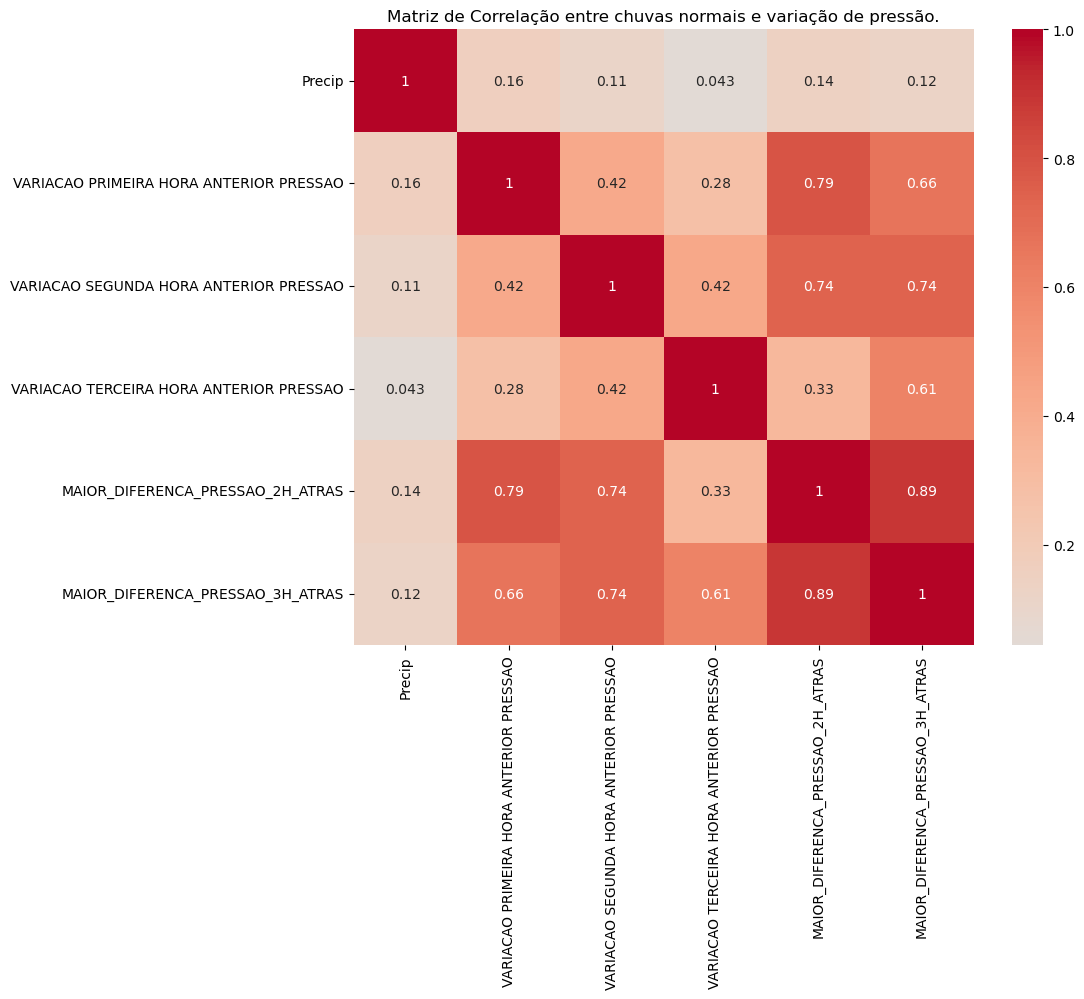

Text(0.5, 1.0, 'Matriz de Correlação entre chuvas extremas e variação de pressão.')

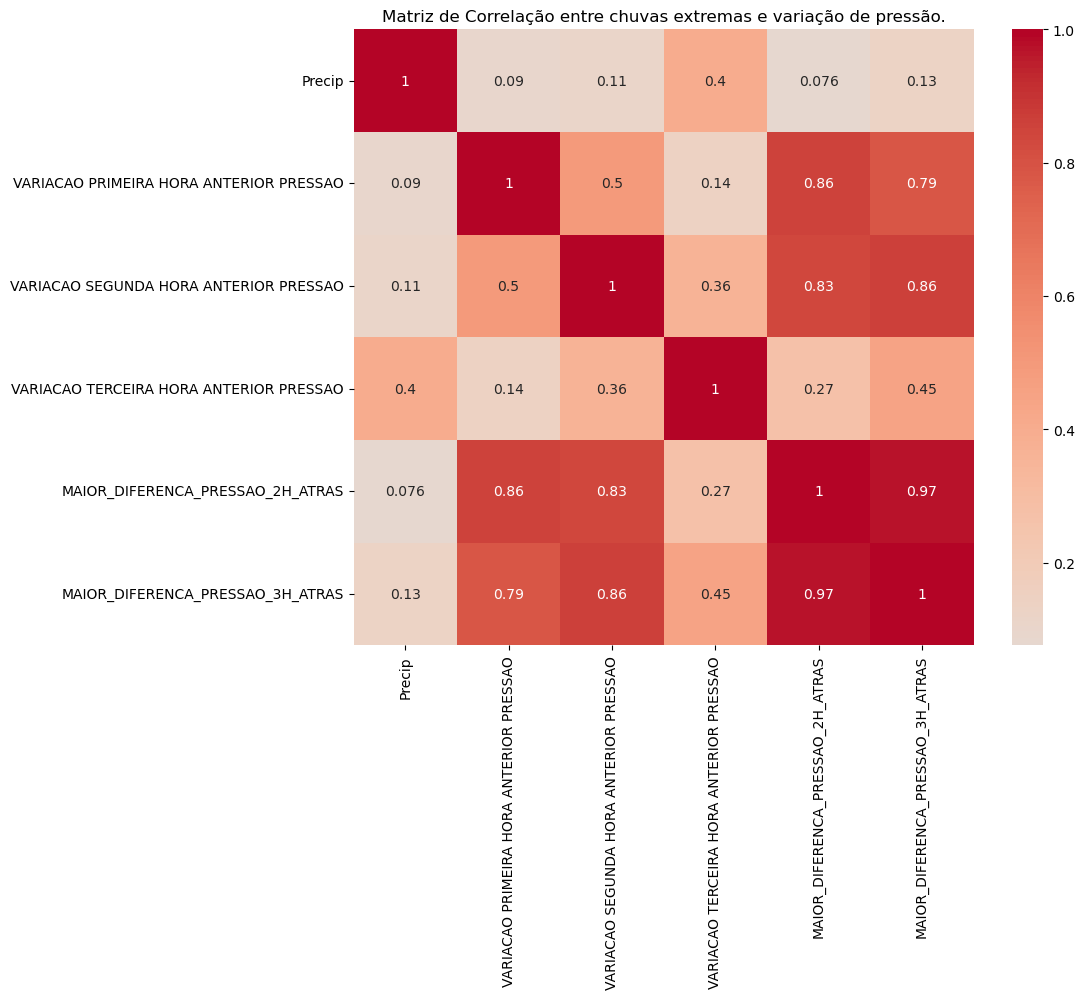

In [66]:
MARAMBAIA = df[df['ESTACAO'] == 'MARAMBAIA'] 

variaveis = ['Dt_Hr', 'ESTACAO','Precip', 'Pres_Atm_max','Pres_Atm_min',
             'VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO',
             'VARIACAO SEGUNDA HORA ANTERIOR PRESSAO',
             'VARIACAO TERCEIRA HORA ANTERIOR PRESSAO']

MARAMBAIA = MARAMBAIA[variaveis]

# Tirando esses nulos.

# Substitui os valores -9999 por NaN
MARAMBAIA.replace(-9999, np.nan, inplace=True)

# Conta a quantidade de valores nulos em cada coluna
missing_values = MARAMBAIA.isnull().sum()

# Exibe a quantidade de valores nulos
print(missing_values)

# Total de valores nulos no DataFrame
total_missing_values = MARAMBAIA.isnull().sum().sum()
print("Total de valores nulos no DataFrame:", total_missing_values) 

len(MARAMBAIA) 

MARAMBAIA = MARAMBAIA.dropna(subset=['Precip'])

MARAMBAIA = MARAMBAIA.reset_index(drop=True)

MARAMBAIA = MARAMBAIA.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)

MARAMBAIA_CHUVA = MARAMBAIA[(MARAMBAIA['Precip'] > 0) & (MARAMBAIA['Precip'] < 25)]

MARAMBAIA_CHUVA_EXTREMA = MARAMBAIA[MARAMBAIA['Precip'] >= 25]

variaveis = ['Precip','VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO','VARIACAO SEGUNDA HORA ANTERIOR PRESSAO','VARIACAO TERCEIRA HORA ANTERIOR PRESSAO',
             'MAIOR_DIFERENCA_PRESSAO_2H_ATRAS','MAIOR_DIFERENCA_PRESSAO_3H_ATRAS'
            
            ]

# Calcula a matriz de correlação
correlation_matrix = MARAMBAIA_CHUVA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas normais e variação de pressão.')

# Exibe o gráfico
plt.show()


# Calcula a matriz de correlação
correlation_matrix = MARAMBAIA_CHUVA_EXTREMA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas extremas e variação de pressão.')


In [67]:
print("MARAMBAIA_CHUVA - VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO:")
print(MARAMBAIA_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'].describe())

print("\nMARAMBAIA_CHUVA_EXTREMA - VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO:")
print(MARAMBAIA_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'].describe())

print("\nMARAMBAIA_CHUVA - VARIACAO TERCEIRA HORA ANTERIOR PRESSAO:")
print(MARAMBAIA_CHUVA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'].describe())

print("\nMARAMBAIA_CHUVA_EXTREMA - VARIACAO TERCEIRA HORA ANTERIOR PRESSAO:")
print(MARAMBAIA_CHUVA_EXTREMA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'].describe())

MARAMBAIA_CHUVA - VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO:
count    13735.000000
mean         0.604157
std          0.438653
min          0.000000
25%          0.300000
50%          0.500000
75%          0.700000
max          8.200000
Name: VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO, dtype: float64

MARAMBAIA_CHUVA_EXTREMA - VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO:
count    46.000000
mean      1.221739
std       0.896391
min       0.200000
25%       0.600000
50%       0.800000
75%       1.700000
max       4.000000
Name: VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO, dtype: float64

MARAMBAIA_CHUVA - VARIACAO TERCEIRA HORA ANTERIOR PRESSAO:
count    13718.000000
mean         0.568363
std          0.386797
min          0.000000
25%          0.300000
50%          0.500000
75%          0.700000
max          5.400000
Name: VARIACAO TERCEIRA HORA ANTERIOR PRESSAO, dtype: float64

MARAMBAIA_CHUVA_EXTREMA - VARIACAO TERCEIRA HORA ANTERIOR PRESSAO:
count    46.000000
mean      0.606522
std       0.37912

# Avaliação de correlação de pressão: VILA MILITAR

Dt_Hr                                         0
ESTACAO                                       0
Precip                                     5709
Pres_Atm_max                               5026
Pres_Atm_min                               5026
VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO    1270
VARIACAO SEGUNDA HORA ANTERIOR PRESSAO     1271
VARIACAO TERCEIRA HORA ANTERIOR PRESSAO    1272
dtype: int64
Total de valores nulos no DataFrame: 19574


C:\Users\Pichau\AppData\Local\Temp\ipykernel_8236\315338091.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  VILA_MILITAR = VILA_MILITAR.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


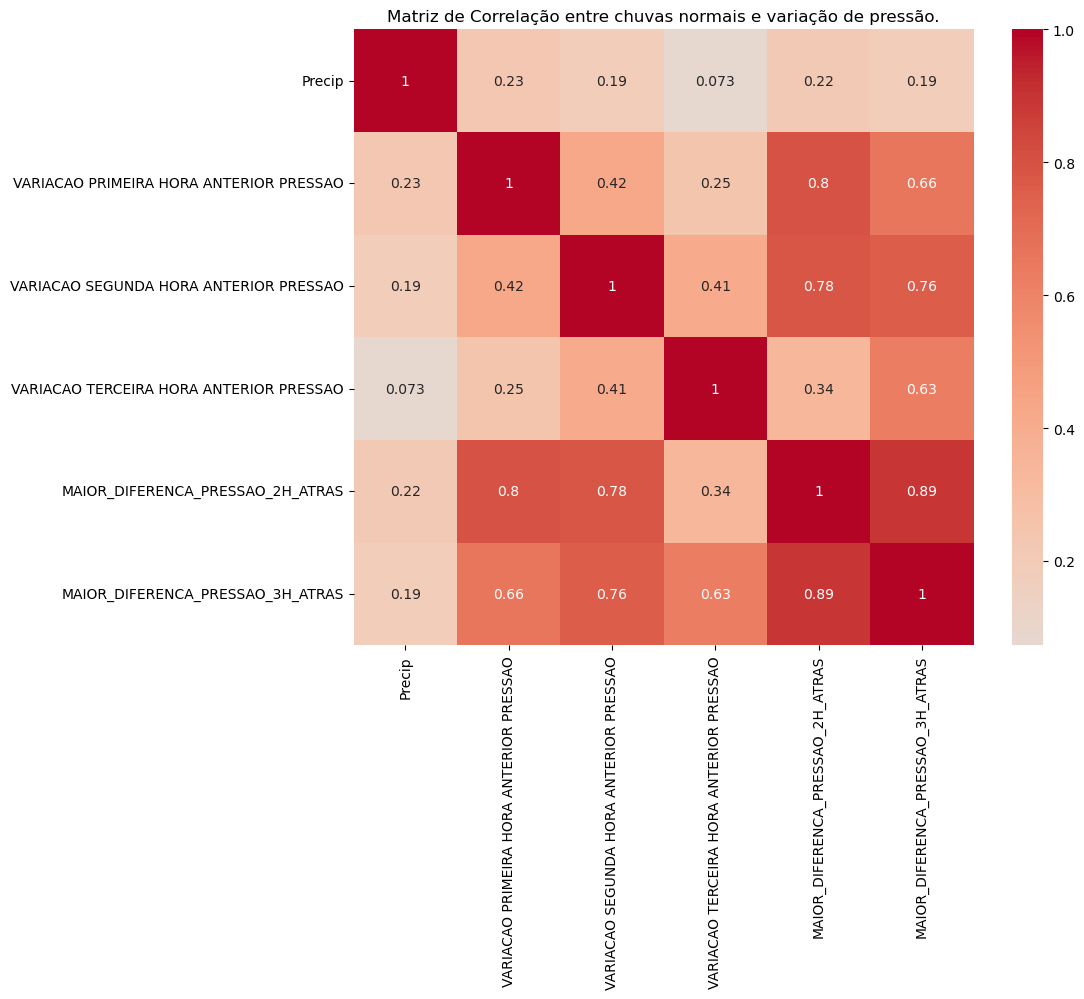

Text(0.5, 1.0, 'Matriz de Correlação entre chuvas extremas e variação de pressão.')

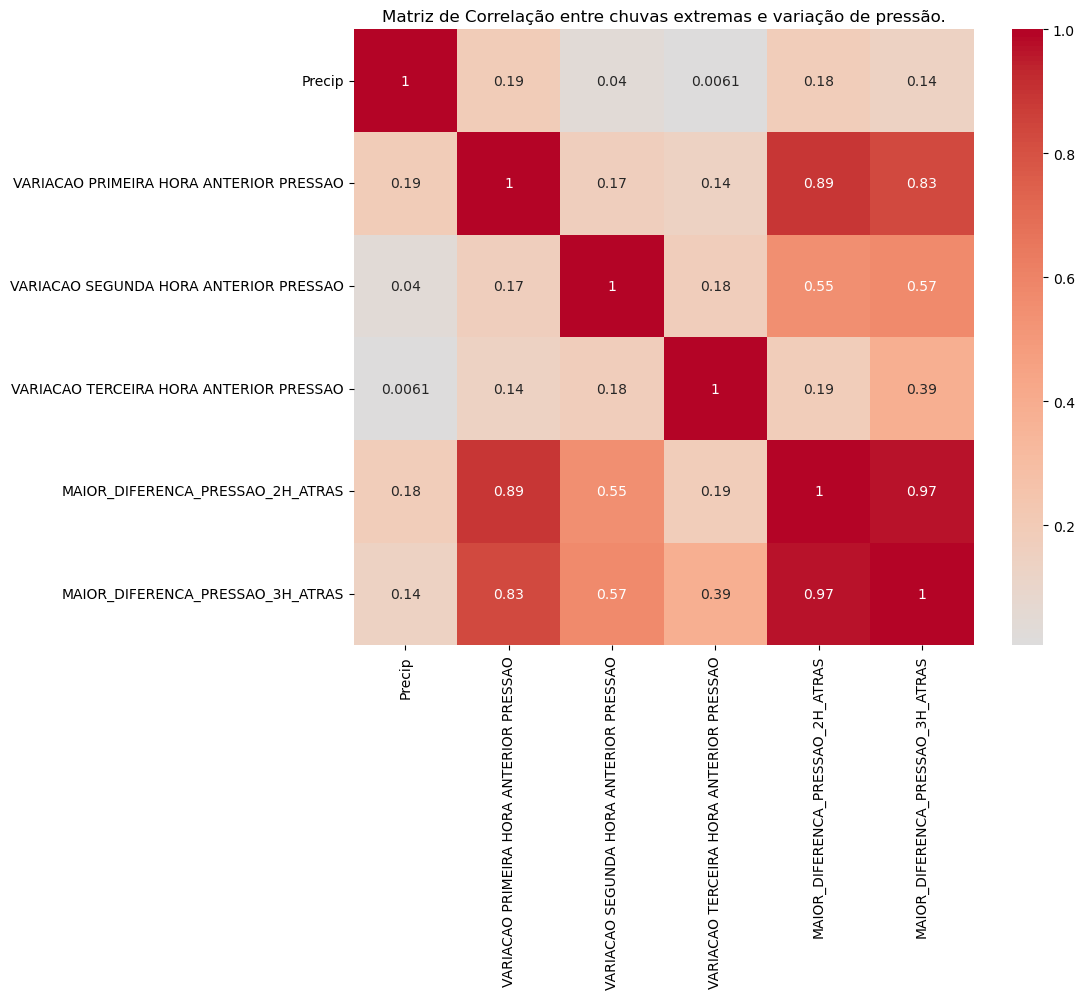

In [69]:
VILA_MILITAR = df[df['ESTACAO'] == 'VILA_MILITAR'] 

variaveis = ['Dt_Hr', 'ESTACAO','Precip', 'Pres_Atm_max','Pres_Atm_min',
             'VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO',
             'VARIACAO SEGUNDA HORA ANTERIOR PRESSAO',
             'VARIACAO TERCEIRA HORA ANTERIOR PRESSAO']

VILA_MILITAR = VILA_MILITAR[variaveis]

# Tirando esses nulos.

# Substitui os valores -9999 por NaN
VILA_MILITAR.replace(-9999, np.nan, inplace=True)

# Conta a quantidade de valores nulos em cada coluna
missing_values = VILA_MILITAR.isnull().sum()

# Exibe a quantidade de valores nulos
print(missing_values)

# Total de valores nulos no DataFrame
total_missing_values = VILA_MILITAR.isnull().sum().sum()
print("Total de valores nulos no DataFrame:", total_missing_values) 

len(VILA_MILITAR) 

VILA_MILITAR = VILA_MILITAR.dropna(subset=['Precip'])

VILA_MILITAR = VILA_MILITAR.reset_index(drop=True)

VILA_MILITAR = VILA_MILITAR.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)

VILA_MILITAR_CHUVA = VILA_MILITAR[(VILA_MILITAR['Precip'] > 0) & (VILA_MILITAR['Precip'] < 25)]

VILA_MILITAR_CHUVA_EXTREMA = VILA_MILITAR[VILA_MILITAR['Precip'] >= 25]

variaveis = ['Precip','VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO','VARIACAO SEGUNDA HORA ANTERIOR PRESSAO','VARIACAO TERCEIRA HORA ANTERIOR PRESSAO',
             'MAIOR_DIFERENCA_PRESSAO_2H_ATRAS','MAIOR_DIFERENCA_PRESSAO_3H_ATRAS'
            
            ]

# Calcula a matriz de correlação
correlation_matrix = VILA_MILITAR_CHUVA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas normais e variação de pressão.')

# Exibe o gráfico
plt.show()


# Calcula a matriz de correlação
correlation_matrix = VILA_MILITAR_CHUVA_EXTREMA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas extremas e variação de pressão.')






In [70]:
print("VILA_MILITAR_CHUVA - VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO:")
print(VILA_MILITAR_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'].describe())

print("\nVILA_MILITAR_CHUVA_EXTREMA - VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO:")
print(VILA_MILITAR_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'].describe())

print("\nVILA_MILITAR_CHUVA - VARIACAO TERCEIRA HORA ANTERIOR PRESSAO:")
print(VILA_MILITAR_CHUVA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'].describe())

print("\nVILA_MILITAR_CHUVA_EXTREMA - VARIACAO TERCEIRA HORA ANTERIOR PRESSAO:")
print(VILA_MILITAR_CHUVA_EXTREMA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'].describe())

VILA_MILITAR_CHUVA - VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO:
count    11527.000000
mean         0.590648
std          0.407958
min          0.000000
25%          0.300000
50%          0.500000
75%          0.700000
max          4.900000
Name: VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO, dtype: float64

VILA_MILITAR_CHUVA_EXTREMA - VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO:
count    74.000000
mean      1.616216
std       1.259379
min       0.200000
25%       0.625000
50%       1.350000
75%       2.100000
max       6.200000
Name: VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO, dtype: float64

VILA_MILITAR_CHUVA - VARIACAO TERCEIRA HORA ANTERIOR PRESSAO:
count    11518.000000
mean         0.571992
std          0.397739
min          0.000000
25%          0.300000
50%          0.500000
75%          0.700000
max          6.600000
Name: VARIACAO TERCEIRA HORA ANTERIOR PRESSAO, dtype: float64

VILA_MILITAR_CHUVA_EXTREMA - VARIACAO TERCEIRA HORA ANTERIOR PRESSAO:
count    74.000000
mean      0.656757
std  

In [71]:
len(VILA_MILITAR_CHUVA_EXTREMA)

74

# Dispersao Copacabana

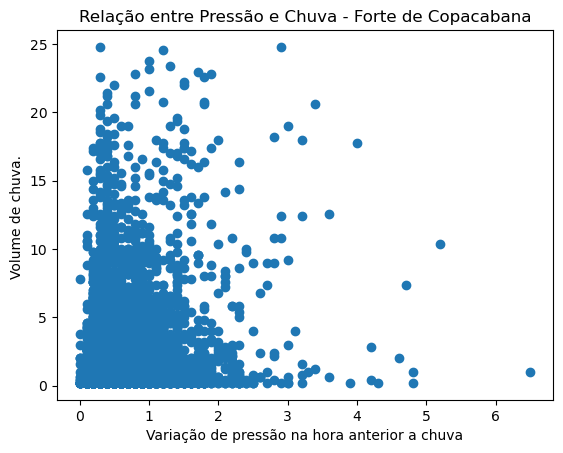

In [73]:

plt.scatter(COPACABANA_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'], COPACABANA_CHUVA['Precip'])

plt.xlabel('Variação de pressão na hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Pressão e Chuva - Forte de Copacabana')

plt.show()




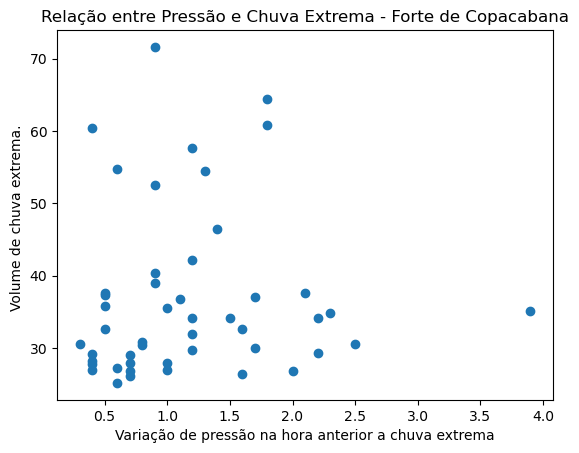

In [74]:
plt.scatter(COPACABANA_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'], COPACABANA_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de pressão na hora anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre Pressão e Chuva Extrema - Forte de Copacabana')

plt.show()


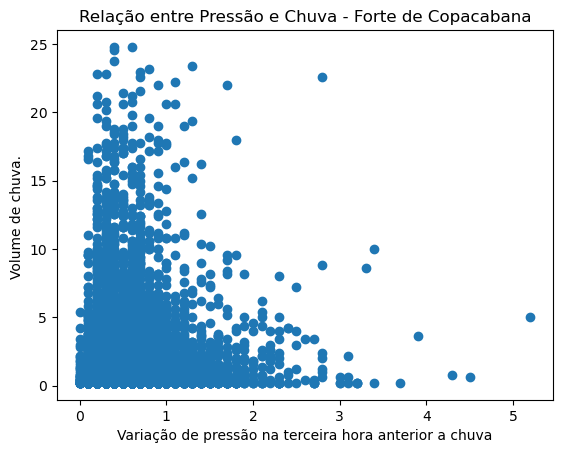

In [75]:
plt.scatter(COPACABANA_CHUVA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'], COPACABANA_CHUVA['Precip'])

plt.xlabel('Variação de pressão na terceira hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Pressão e Chuva - Forte de Copacabana')

plt.show()

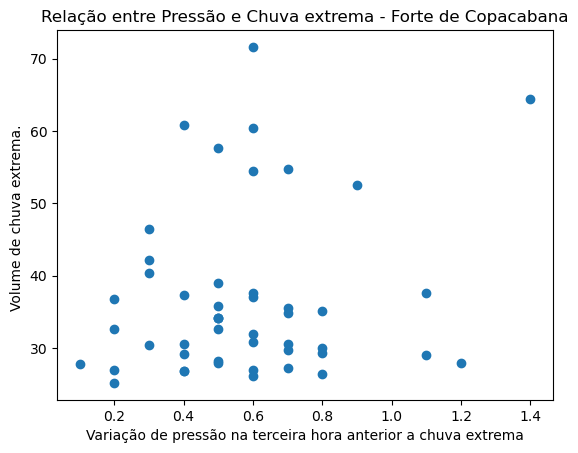

In [76]:
plt.scatter(COPACABANA_CHUVA_EXTREMA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'], COPACABANA_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de pressão na terceira hora anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre Pressão e Chuva extrema - Forte de Copacabana')

plt.show()


# Dispersão Jacarepagua. 

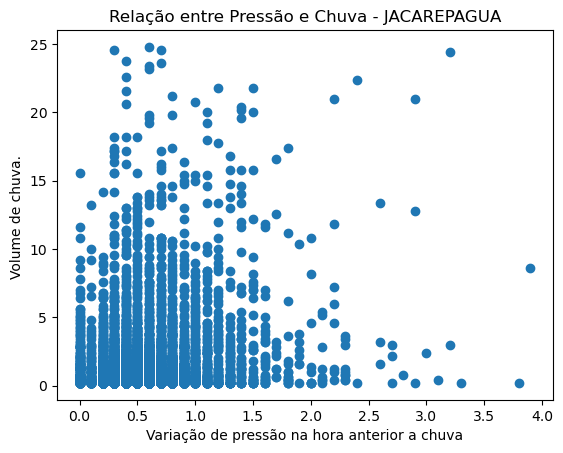

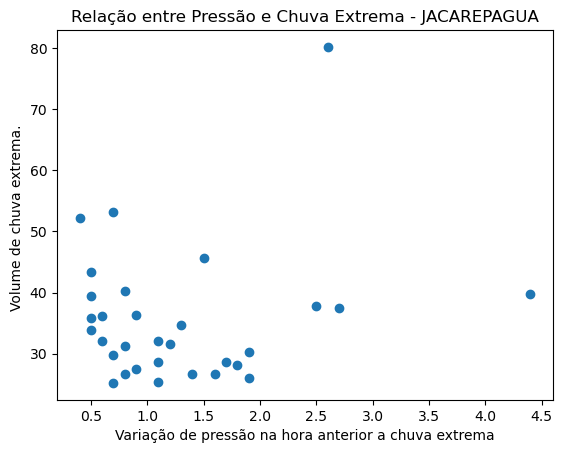

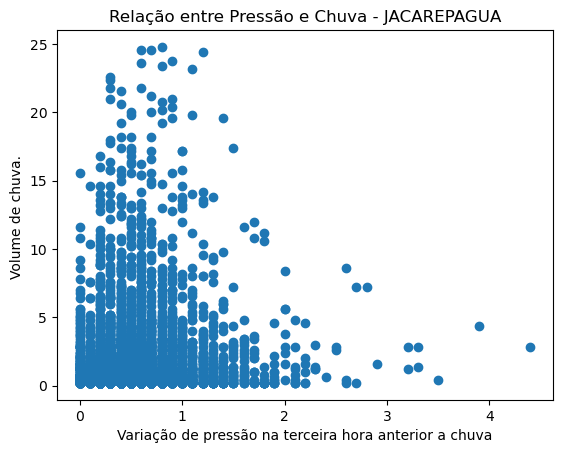

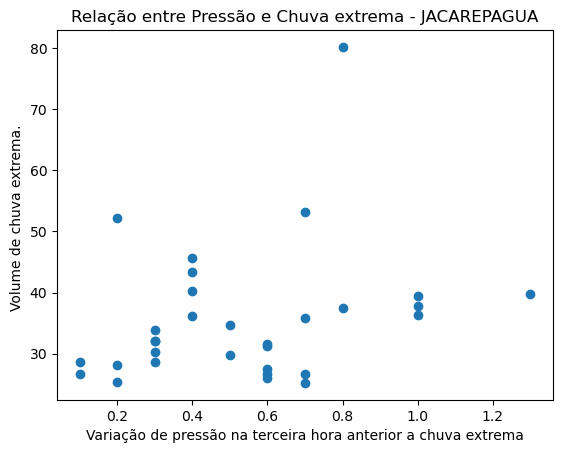

In [78]:
plt.scatter(JACAREPAGUA_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'], JACAREPAGUA_CHUVA['Precip'])

plt.xlabel('Variação de pressão na hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Pressão e Chuva - JACAREPAGUA')

plt.show()


plt.scatter(JACAREPAGUA_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'], JACAREPAGUA_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de pressão na hora anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre Pressão e Chuva Extrema - JACAREPAGUA')

plt.show()

plt.scatter(JACAREPAGUA_CHUVA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'], JACAREPAGUA_CHUVA['Precip'])

plt.xlabel('Variação de pressão na terceira hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Pressão e Chuva - JACAREPAGUA')

plt.show()

plt.scatter(JACAREPAGUA_CHUVA_EXTREMA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'], JACAREPAGUA_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de pressão na terceira hora anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre Pressão e Chuva extrema - JACAREPAGUA')

plt.show()

# Dispersão MARAMBAIA

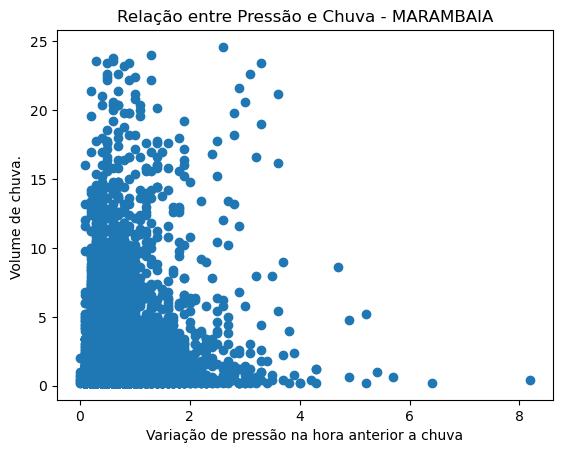

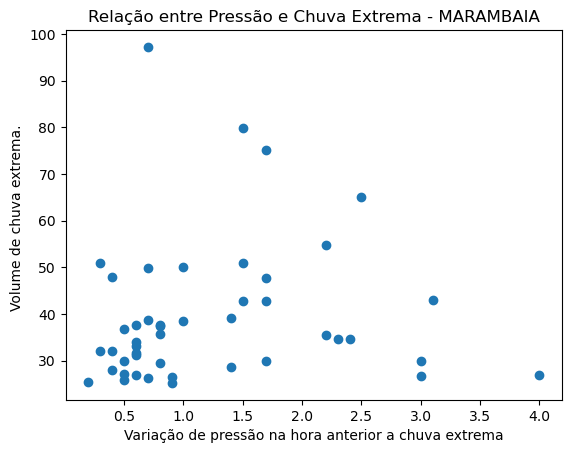

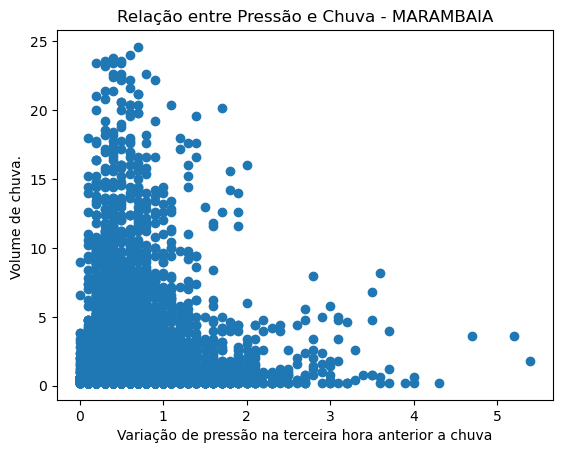

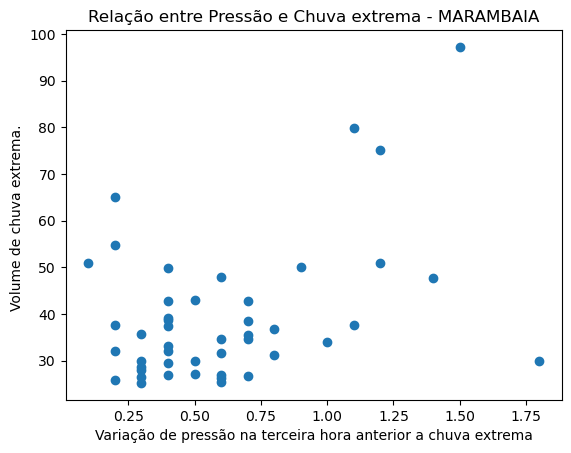

In [80]:
plt.scatter(MARAMBAIA_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'], MARAMBAIA_CHUVA['Precip'])

plt.xlabel('Variação de pressão na hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Pressão e Chuva - MARAMBAIA')

plt.show()


plt.scatter(MARAMBAIA_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'], MARAMBAIA_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de pressão na hora anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre Pressão e Chuva Extrema - MARAMBAIA')

plt.show()

plt.scatter(MARAMBAIA_CHUVA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'], MARAMBAIA_CHUVA['Precip'])

plt.xlabel('Variação de pressão na terceira hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Pressão e Chuva - MARAMBAIA')

plt.show()

plt.scatter(MARAMBAIA_CHUVA_EXTREMA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'], MARAMBAIA_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de pressão na terceira hora anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre Pressão e Chuva extrema - MARAMBAIA')

plt.show()

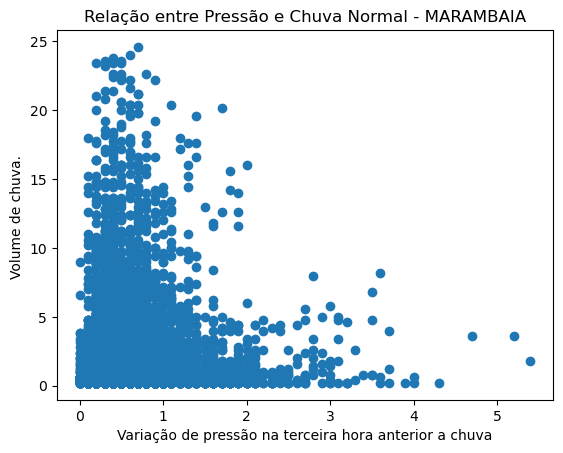

In [81]:
plt.scatter(MARAMBAIA_CHUVA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'], MARAMBAIA_CHUVA['Precip'])

plt.xlabel('Variação de pressão na terceira hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Pressão e Chuva Normal - MARAMBAIA')

plt.show()

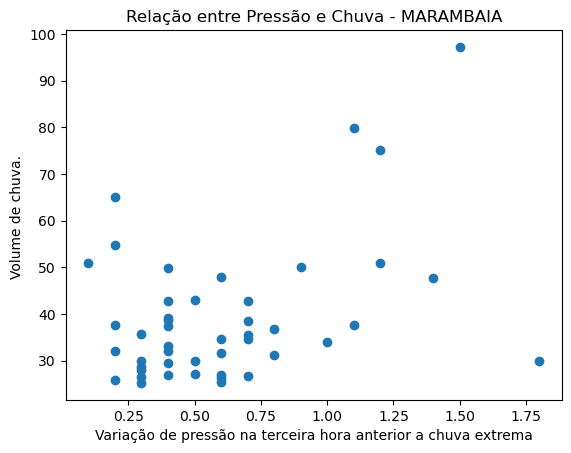

In [82]:
plt.scatter(MARAMBAIA_CHUVA_EXTREMA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'], MARAMBAIA_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de pressão na terceira hora anterior a chuva extrema')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Pressão e Chuva - MARAMBAIA')

plt.show()

# Dispersão VILA MILITAR

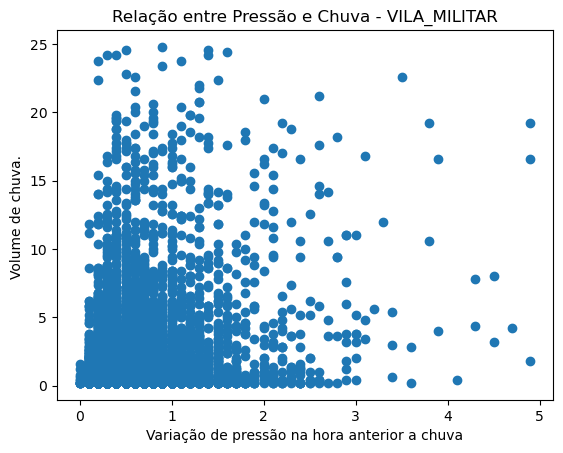

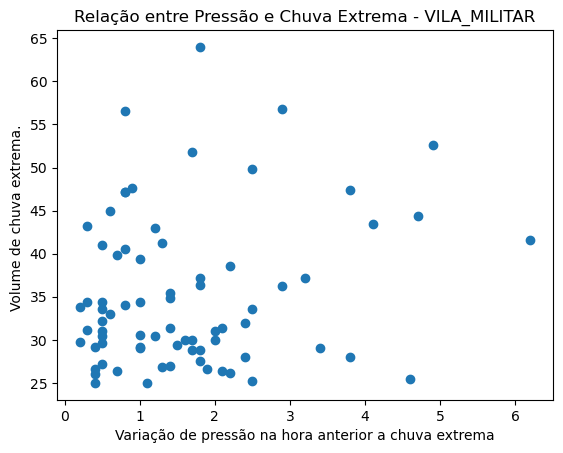

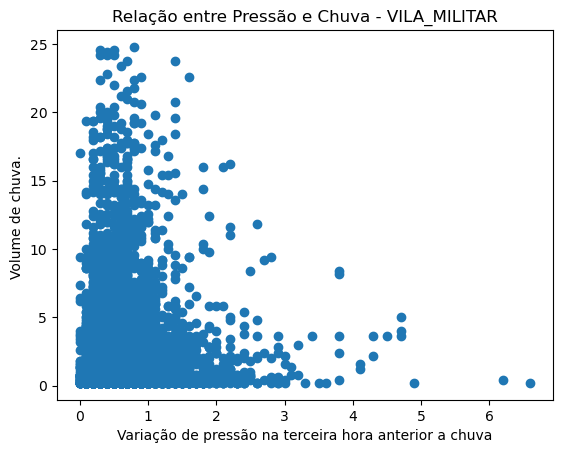

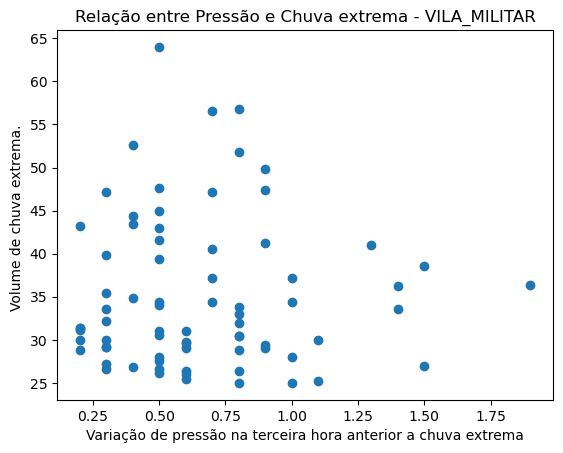

In [84]:
plt.scatter(VILA_MILITAR_CHUVA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'], VILA_MILITAR_CHUVA['Precip'])

plt.xlabel('Variação de pressão na hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Pressão e Chuva - VILA_MILITAR')

plt.show()


plt.scatter(VILA_MILITAR_CHUVA_EXTREMA['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'], VILA_MILITAR_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de pressão na hora anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre Pressão e Chuva Extrema - VILA_MILITAR')

plt.show()

plt.scatter(VILA_MILITAR_CHUVA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'], VILA_MILITAR_CHUVA['Precip'])

plt.xlabel('Variação de pressão na terceira hora anterior a chuva')

plt.ylabel('Volume de chuva. ')

plt.title('Relação entre Pressão e Chuva - VILA_MILITAR')

plt.show()

plt.scatter(VILA_MILITAR_CHUVA_EXTREMA['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'], VILA_MILITAR_CHUVA_EXTREMA['Precip'])

plt.xlabel('Variação de pressão na terceira hora anterior a chuva extrema')

plt.ylabel('Volume de chuva extrema. ')

plt.title('Relação entre Pressão e Chuva extrema - VILA_MILITAR')

plt.show()

In [128]:
MARAMBAIA_CHUVA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO,VARIACAO SEGUNDA HORA ANTERIOR PRESSAO,VARIACAO TERCEIRA HORA ANTERIOR PRESSAO,MAIOR_DIFERENCA_PRESSAO_2H_ATRAS,MAIOR_DIFERENCA_PRESSAO_3H_ATRAS
count,13736.000000,13735.000000,13728.000000,13718.000000,13729.000000,13729.000000
mean,1.485847,0.604157,0.589277,0.568363,1.056217,1.452750
std,2.501179,0.438653,0.409514,0.386797,0.691175,0.868601
min,0.200000,0.000000,0.000000,0.000000,0.100000,0.100000
25%,0.200000,0.300000,0.300000,0.300000,0.600000,0.900000
50%,0.600000,0.500000,0.500000,0.500000,0.900000,1.300000
75%,1.600000,0.700000,0.700000,0.700000,1.300000,1.800000
max,24.600000,8.200000,5.700000,5.400000,16.700000,16.700000


In [130]:
MARAMBAIA_CHUVA_EXTREMA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO,VARIACAO SEGUNDA HORA ANTERIOR PRESSAO,VARIACAO TERCEIRA HORA ANTERIOR PRESSAO,MAIOR_DIFERENCA_PRESSAO_2H_ATRAS,MAIOR_DIFERENCA_PRESSAO_3H_ATRAS
count,46.000000,46.000000,46.000000,46.000000,46.000000,46.00000
mean,39.343478,1.221739,1.030435,0.606522,1.960870,2.33913
std,15.180904,0.896391,0.903295,0.379123,1.432399,1.62460
min,25.200000,0.200000,0.100000,0.100000,0.300000,0.50000
25%,29.500000,0.600000,0.500000,0.325000,0.800000,1.12500
50%,35.000000,0.800000,0.700000,0.500000,1.550000,1.80000
75%,42.950000,1.700000,1.175000,0.700000,2.800000,2.97500
max,97.200000,4.000000,4.000000,1.800000,5.900000,6.50000


In [132]:
VILA_MILITAR_CHUVA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO,VARIACAO SEGUNDA HORA ANTERIOR PRESSAO,VARIACAO TERCEIRA HORA ANTERIOR PRESSAO,MAIOR_DIFERENCA_PRESSAO_2H_ATRAS,MAIOR_DIFERENCA_PRESSAO_3H_ATRAS
count,11532.000000,11527.000000,11522.000000,11518.000000,11525.000000,11523.000000
mean,1.493757,0.590648,0.588839,0.571992,1.051566,1.464133
std,2.700741,0.407958,0.423675,0.397739,0.650728,0.841773
min,0.200000,0.000000,0.000000,0.000000,0.100000,0.100000
25%,0.200000,0.300000,0.300000,0.300000,0.600000,0.900000
50%,0.400000,0.500000,0.500000,0.500000,0.900000,1.300000
75%,1.400000,0.700000,0.700000,0.700000,1.300000,1.800000
max,24.800000,4.900000,6.600000,6.600000,6.900000,8.000000


In [134]:
VILA_MILITAR_CHUVA_EXTREMA[variaveis].describe()

,Precip,VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO,VARIACAO SEGUNDA HORA ANTERIOR PRESSAO,VARIACAO TERCEIRA HORA ANTERIOR PRESSAO,MAIOR_DIFERENCA_PRESSAO_2H_ATRAS,MAIOR_DIFERENCA_PRESSAO_3H_ATRAS
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,35.113514,1.616216,1.022973,0.656757,2.420270,2.820270
std,8.705853,1.259379,0.643098,0.352712,1.482314,1.540857
min,25.000000,0.200000,0.200000,0.200000,0.400000,0.500000
25%,29.000000,0.625000,0.525000,0.400000,1.325000,1.725000
50%,32.100000,1.350000,0.800000,0.600000,2.300000,2.700000
75%,40.400000,2.100000,1.375000,0.800000,3.075000,3.800000
max,64.000000,6.200000,3.000000,1.900000,7.600000,7.800000
